In [3]:
import pandas as pd
import shutil
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar Imágenes y redimensionarlas

In [ ]:
categorias = ['normal','benigno', 'maligno']

In [ ]:
import os
import cv2
import numpy as np

def read_imageResize_with_labels(dir='../database/dataset', target_size=(224, 224)):
    """
    Lee imágenes de un directorio, las redimensiona a 224x224 píxeles y las etiqueta según 
    la subcarpeta en la que se encuentran. Las imágenes son procesadas en escala de grises.

    Parámetros:
    dir (str): La ruta del directorio principal que contiene las subcarpetas con las imágenes. 
               Las subcarpetas deben llamarse 'normal', 'benigno' y 'maligno' para que 
               las etiquetas se asignen correctamente. Las subcarpetas no definidas 
               recibirán una etiqueta de -1.

    Retorno:
    tuple: Una tupla que contiene dos elementos:
        - np.array: Un array de NumPy con las imágenes redimensionadas.
        - list: Una lista de etiquetas correspondientes a las imágenes.
    """
    labels = []
    imgs = []
    
    for subfolder in os.listdir(dir):
        subfolder_path = os.path.join(dir, subfolder)
        
        # Ignorar si no es un directorio
        if not os.path.isdir(subfolder_path):
            continue
            
        # Asignar la etiqueta en función del nombre de la subcarpeta
        label = -1
        if subfolder == 'normal':
            label = 0
        elif subfolder == 'benigno':
            label = 1
        elif subfolder == 'maligno':
            label = 2
        
        # Procesar imágenes solo si la carpeta tiene una etiqueta válida
        if label != -1:
            for name_image in os.listdir(subfolder_path):
                image_path = os.path.join(subfolder_path, name_image)
                
                # Cargar la imagen en escala de grises
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                
                # Asegurarse de que la imagen se cargó correctamente
                if image is not None:
                    # Redimensionar la imagen a `target_size` con interpolación bicúbica
                    resized_image = cv2.resize(image, target_size, interpolation=cv2.INTER_CUBIC)
                    
                    imgs.append(resized_image)
                    labels.append(label)
    
    return np.array(imgs), labels

In [ ]:
# Leer las imagenes originales con sus etiquetas

imgs, labels = read_imageResize_with_labels(dir='database/dataset')

In [ ]:
# Comprobar la cantidad
print(imgs.shape)
print(len(labels))

(3608, 224, 224)
3608


In [ ]:
# Verificar normalizacion
unicos = np.unique(imgs[0])
max(unicos)

255

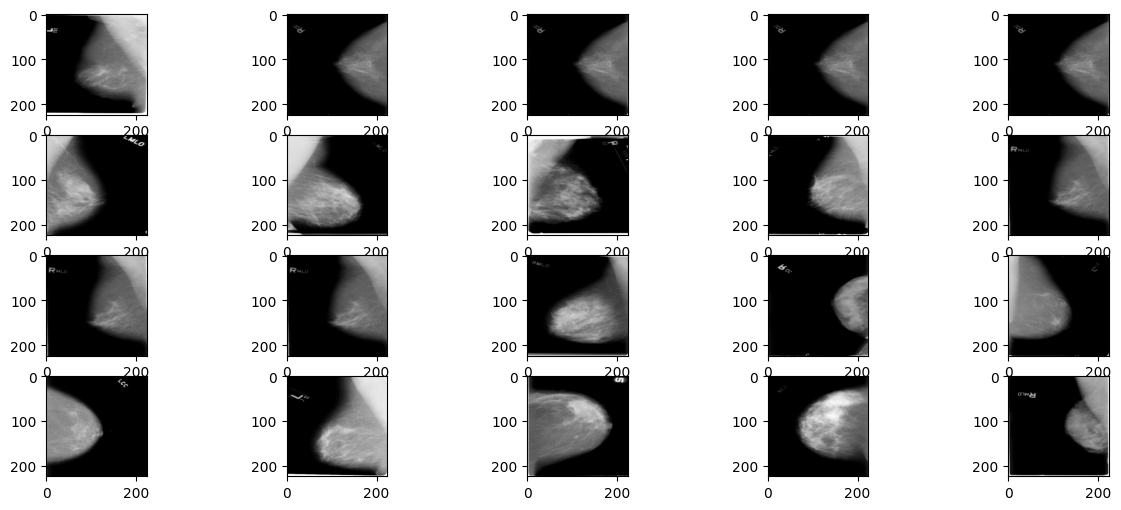

In [ ]:
import matplotlib.pyplot as plt
def show_imgs(imgs):
    '''
    Muestra una lista de imágenes en una matriz de 2 filas y 5 columnas utilizando Matplotlib.

    Parametros:
    - imgs: Una lista de matrices numpy representando las imágenes a mostrar.
    
    Esta función crea una figura con subtramas dispuestas en una matriz de 2x5.
    Recorre la lista de imágenes y las muestra en estas subtramas. Si hay menos de
    10 imágenes en la lista, los espacios restantes en la matriz quedan en blanco.
    '''
    fig, axes = plt.subplots(4, 5, figsize=(15, 6))

    for i in range(4):
        for j in range(5):
            if i*5 + j < len(imgs):
                axes[i, j].imshow(imgs[i*5 + j],cmap = 'gray')
                #axes[i, j].axis('off')

    plt.show()
    
show_imgs(imgs)

### Cantidad de imágenes y categorias 

In [ ]:
unique_labels, unique_counts = np.unique(labels, return_counts=True)

# Crea un diccionario con las etiquetas y sus conteos
labels_histogram = dict(zip(unique_labels, unique_counts))

print(labels_histogram)

{0: 207, 1: 1995, 2: 1406}


In [ ]:
labels = np.array(labels)
print(f"Tamaño de imgs: {imgs.shape}")
print(f"Tamaño de labels: {labels.shape}")


Tamaño de imgs: (3608, 224, 224)
Tamaño de labels: (3608,)


In [ ]:
print(f"Imágenes con etiqueta 1 (benigno): {np.sum(labels == 1)}")

Imágenes con etiqueta 1 (benigno): 1995


# Split 

In [ ]:
def get_patient_id(filename):
    """
    Extrae el ID del paciente del nombre del archivo.
    Asume que el ID está separado por '_', '-' o un espacio.
    """
    basename = os.path.splitext(filename)[0]
    for sep in ['_', '-', ' ']:
        if sep in basename:
            return basename.split(sep)[0]
    return basename

In [ ]:
def get_patient_ids_in_order(dir='database/dataset'):
    """
    Obtiene los IDs de los pacientes exactamente en el mismo orden 
    en que la función original de lectura de imágenes los procesó.
    """
    label_map = {'normal': 0, 'benigno': 1, 'maligno': 2}
    patient_ids = []
    
    for subfolder in os.listdir(dir):
        subfolder_path = os.path.join(dir, subfolder)
        if not os.path.isdir(subfolder_path) or subfolder not in label_map:
            continue
            
        for name_image in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, name_image)
            # Verificación rápida para asegurar que solo contamos imágenes válidas,
            # manteniendo las listas perfectamente alineadas con las imágenes cargadas.
            if cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) is None:
                continue
            
            patient_ids.append(get_patient_id(name_image))
            
    return np.array(patient_ids)

In [ ]:
def split_patientwise_preloaded(imgs, labels, patient_ids, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Divide el dataset a nivel de paciente utilizando las imágenes y etiquetas 
    que ya están cargadas en memoria. Esto evita que los datos de un mismo 
    paciente queden divididos entre los conjuntos de entrenamiento y prueba.
    """
    patient_to_indices = {}
    for idx, pid in enumerate(patient_ids):
        patient_to_indices.setdefault(pid, []).append(idx)

    patient_ids_list = list(patient_to_indices.keys())
    rng = np.random.default_rng(random_state)
    rng.shuffle(patient_ids_list)

    n = len(patient_ids_list)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    # Agrupar pacientes en los conjuntos correspondientes
    train_patients = set(patient_ids_list[:n_train])
    val_patients = set(patient_ids_list[n_train:n_train + n_val])
    test_patients = set(patient_ids_list[n_train + n_val:])

    # Obtener los índices de las imágenes correspondientes a los pacientes de cada conjunto
    train_idx = [i for pid in train_patients for i in patient_to_indices[pid]]
    val_idx = [i for pid in val_patients for i in patient_to_indices[pid]]
    test_idx = [i for pid in test_patients for i in patient_to_indices[pid]]

    return (
        imgs[train_idx], labels[train_idx], train_patients,
        imgs[val_idx], labels[val_idx], val_patients,
        imgs[test_idx], labels[test_idx], test_patients,
    )

In [ ]:
# 1. Obtener los IDs de los pacientes (esto es bastante rápido ya que omite el redimensionamiento)
patient_ids = get_patient_ids_in_order(dir='database/dataset')

# 2. Verificación rápida de cordura para asegurar que nuestros arreglos coincidan en tamaño
if len(patient_ids) == len(imgs):
    # 3. Realizar la partición usando los datos preexistentes
    train_imgs, train_labels, train_patients, \
    val_imgs, val_labels, val_patients, \
    test_imgs, test_labels, test_patients = split_patientwise_preloaded(imgs, labels, patient_ids)

    print("Train:", train_imgs.shape, train_labels.shape, len(train_patients))
    print("Validation:", val_imgs.shape, val_labels.shape, len(val_patients))
    print("Test:", test_imgs.shape, test_labels.shape, len(test_patients))
else:
    print(f"¡ hay una discrepancia! IDs de pacientes: {len(patient_ids)}, Imágenes: {len(imgs)}. ")

Train: (2595, 224, 224) (2595,) 435
Validation: (516, 224, 224) (516,) 93
Test: (497, 224, 224) (497,) 94


In [ ]:

def save_split_dataset(imgs, labels, subset_name, base_dir='database/datasetV3'):
    """
    Guarda los arreglos de imágenes y etiquetas en una nueva estructura de carpetas.
    Crea automáticamente directorios como: base_dir/subset_name/clase/
    """
    # Diccionario para mapear los números de vuelta a los nombres de las carpetas originales
    label_map_reverse = {0: 'normal', 1: 'benigno', 2: 'maligno'}
    
    for i, (img, label) in enumerate(zip(imgs, labels)):
        # Obtener el nombre de la clase (ej. 'benigno')
        class_name = label_map_reverse[label]
        
        # Crear la ruta de la carpeta si no existe (ej. 'database/dataset_split/train/benigno')
        save_dir = os.path.join(base_dir, subset_name, class_name)
        os.makedirs(save_dir, exist_ok=True)
        
        # Crear un nombre de archivo único para la imagen
        filename = f"{class_name}_{i}.png"
        filepath = os.path.join(save_dir, filename)
        
        # Guardar la imagen en el disco duro
        cv2.imwrite(filepath, img)
    
    print(f"Conjunto '{subset_name}' guardado exitosamente en: {os.path.join(base_dir, subset_name)}")

# ==========================================
# Ejecución para guardar los tres conjuntos
# ==========================================

# 1. Guardar el conjunto de entrenamiento (Train)
save_split_dataset(train_imgs, train_labels, subset_name='train', base_dir='database/datasetV3')

# 2. Guardar el conjunto de validación (Validation)
save_split_dataset(val_imgs, val_labels, subset_name='val', base_dir='database/datasetV3')

# 3. Guardar el conjunto de pruebas (Test)
save_split_dataset(test_imgs, test_labels, subset_name='test', base_dir='database/dataseV3')